# Projeto DL-2024: Extração e Clusterização de Entidades em Textos Científicos

**Objetivo:** Este projeto implementa um pipeline híbrido de Processamento de Linguagem Natural (PLN). A arquitetura é composta pelas seguintes etapas:
1. **Treinamento de um Modelo Customizado (SpaCy NER):** Criamos nosso próprio *corpus* de treinamento para ensinar a IA a reconhecer entidades do domínio da Bioeconomia (`PRODUTO`, `EMPRESA`, `TECNOLOGIA` e `MATERIA_PRIMA`). Em um ambiente de produção real, esse conjunto seria expandido via ferramentas de anotação gráfica para garantir um balanceamento estrito de classes e evitar viés (*bias*).
2. **Concatenação:** As entidades extraídas são reintegradas ao *DataFrame* original para enriquecimento dos dados.
3. **Embeddings Semânticos:** Os termos são convertidos em vetores densos utilizando a arquitetura Transformer (`paraphrase-multilingual-MiniLM-L12-v2`).
4. **Machine Learning:** Os vetores são agrupados por similaridade matemática usando **K-Means** (otimizado via *Silhouette Score*) e projetados no espaço 2D com **t-SNE**.

In [2]:
# Instalação das bibliotecas necessárias para o pipeline de PLN e Machine Learning
!pip install -q spacy transformers sentence-transformers scikit-learn matplotlib seaborn
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 48.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Importação das bibliotecas e configuração do ambiente
import pandas as pd
import spacy
from spacy.training.example import Example
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar alertas de depreciação para manter o log de execução limpo
warnings.filterwarnings("ignore")
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### 1. Aquisição e Preparação dos Dados
Carregamento do dataset oficial da disciplina. Realizamos o tratamento da codificação (`latin1`) para a leitura correta de acentuações da língua portuguesa e a higienização de registros nulos.

In [4]:
# Definição do caminho do arquivo no ambiente Kaggle
caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv' 

# Carregamento dos dados com tratamento de caracteres especiais
df = pd.read_csv(caminho_arquivo, sep='\t', encoding='latin1')

# Remoção de registros sem descrição para garantir a qualidade do modelo
df = df.dropna(subset=['Descricao_pública']).reset_index(drop=True)

print(f"Total de projetos aptos para processamento: {len(df)}")
display(df.head(2))

Total de projetos aptos para processamento: 2721


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...


### 2. Treinamento da Rede Neural de Extração (NER)
Para fins pedagógicos, instruímos o algoritmo manualmente através de um conjunto estruturado (`TRAIN_DATA`). Misturamos frases curtas para reconhecimento de padrões diretos e textos densos do próprio dataset para avaliação do contexto periférico.

In [5]:
# Construção do corpus de treinamento (Anotação de entidades-chave)
TRAIN_DATA = [
    # --- EXEMPLOS CURTOS (Aprendizado de padrões diretos) ---
    ("produtos oriundos das florestas brasileiras", {"entities": [(22, 43, "MATERIA_PRIMA")]}),
    ("linha de farofas com castanhas brasileiras", {"entities": [(21, 42, "MATERIA_PRIMA")]}),
    ("adição de proteína animal na composição", {"entities": [(10, 25, "MATERIA_PRIMA")]}),
    ("diversidade da flora dos fragmentos avaliados", {"entities": [(15, 20, "MATERIA_PRIMA")]}),
    ("Açúcar de frutas e aplicação em bolos como substituto da sacarose", {"entities": [(0, 16, "PRODUTO"), (57, 65, "MATERIA_PRIMA")]}),
    ("produzir frutose em pó que substitua a sacarose", {"entities": [(9, 22, "PRODUTO"), (39, 47, "MATERIA_PRIMA")]}),
    ("Plataforma Digital de Bioinsumos na Cafeicultura", {"entities": [(22, 32, "PRODUTO")]}),
    ("uso de inovações tecnológicas auxilia as indústrias", {"entities": [(7, 29, "TECNOLOGIA")]}),
    ("desenvolver uma tecnologia inovadora que possibilite", {"entities": [(16, 36, "TECNOLOGIA")]}),
    ("plataforma de Infraestrutura de dados espaciais (IDE)", {"entities": [(14, 47, "TECNOLOGIA")]}),
    ("adaptando os algoritmos existentes para otimizar", {"entities": [(13, 34, "TECNOLOGIA")]}),
    ("tecnologia inovadora que possibilite à Suzano mapear", {"entities": [(39, 45, "EMPRESA")]}),
    ("presente no contexto da Klabin neste ano.", {"entities": [(24, 30, "EMPRESA")]}),
    ("estabelecidos pela Organização das Nações Unidas (ONU)", {"entities": [(19, 48, "EMPRESA"), (50, 53, "EMPRESA")]}),

    # --- TEXTOS REAIS (Aprendizado do contexto longo) ---
    (
        "O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contribui para os Objetivos de Desenvolvimento Sustentável (ODS) estabelecidos pela Organização das Nações Unidas (ONU) especialmente no âmbito do Objetivo 12 (Assegurar padrões de produção e de consumo sustentáveis). Diante desse cenário, a presenta proposta buscará desenvolver e produzir frutose em pó que substitua a sacarose para atender o mercado de indústrias de alimentos.", 
        {"entities": [(9, 31, "TECNOLOGIA"), (346, 375, "EMPRESA"), (377, 380, "EMPRESA"), (537, 550, "PRODUTO"), (567, 575, "MATERIA_PRIMA")]}
    ),
    (
        "O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a necessidade de pesquisas com o objetivo de desenvolver produto inovador pronto para consumo, agregação de valor e diferenciação de sabores, em especial produtos oriundos das florestas brasileiras que contribuem para o desenvolvimento da bioeconomia no Brasil. Esse estudo também se propõe a avaliar as características do novo produto para fins de informação nutricional da rotulagem e acompanhar o período de vida útil do produto. A empresa está em busca de apoio na inovação e melhoria dos processos para desenvolver uma linha de produção sustentável com o uso de castanhas brasileiras, devido a grande diversidade dessas castanhas com alto valor nutricional e com sabor, aroma e alto nível de aceitação ampliando a diversificação de produtos.", 
        {"entities": [(9, 31, "TECNOLOGIA"), (681, 702, "MATERIA_PRIMA"), (737, 746, "MATERIA_PRIMA")]}
    ),
    (
        "O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mata Atlântica e Cerrado, onde são encontradas plantas frutíferas nativas e importadas que possuem características nutricionais importantes. Dessa forma, busca-se desenvolver produtos inovadores com base nessas espécies promovendo o Desenvolvimento Sustentável (DS) com benefícios ambientais, sociais e econômicos, o que contribui para o desenvolvimento da bioeconomia no Brasil. A presente proposta está diretamente ligada à utilização de processos tecnológicos/biotecnológicos para o desenvolvimento e valorização de produtos a partir de Plantas Alimentícias Não Convencionais (PANC), alimentos e nutrição humana, linhas estas, relacionados aos Objetivos de Desenvolvimento Sustentável (ODS) da Organização das Nações Unidas (ONU).", 
        {"entities": [(163, 189, "MATERIA_PRIMA"), (544, 582, "TECNOLOGIA"), (650, 688, "MATERIA_PRIMA"), (690, 694, "MATERIA_PRIMA"), (812, 841, "EMPRESA"), (843, 846, "EMPRESA")]}
    )
]

# Inicialização de um modelo SpaCy nativo e alocação do pipeline de NER
nlp_treino = spacy.blank("pt")
ner = nlp_treino.add_pipe("ner", last=True)

# Registro dinâmico das categorias no pipeline
for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

# Otimização e convergência dos pesos da rede
print("Iniciando o treinamento da rede neural do SpaCy...")
optimizer = nlp_treino.begin_training()

for itn in range(30): # 30 ciclos de épocas
    random.shuffle(TRAIN_DATA)
    losses = {}
    for text, annotations in TRAIN_DATA:
        doc = nlp_treino.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp_treino.update([example], drop=0.3, sgd=optimizer, losses=losses)
        
print("Treinamento concluído. Salvando o modelo em disco...")
nlp_treino.to_disk("./meu_modelo_ner_dl2024")

Iniciando o treinamento da rede neural do SpaCy...
Treinamento concluído. Salvando o modelo em disco...


### 3. Aplicação do Modelo e Enriquecimento do Dataset
O modelo treinado é percorrido sobre o *DataFrame*. Realizamos um pós-processamento para mitigar ruídos (extrações excessivamente curtas ou pontuações) e concatenamos os resultados na tabela original.

In [6]:
# Carregamento do nosso modelo validado
nlp_carregado = spacy.load("./meu_modelo_ner_dl2024")

def extrair_entidades(texto):
    """
    Processa o texto alvo e retorna uma string contendo entidades únicas,
    limpas e formatadas em minúsculas para padronização.
    """
    if pd.isna(texto): return ""
    doc = nlp_carregado(texto)
    
    # Filtro sintático e limpeza de ruídos
    entidades = [ent.text.strip().lower() for ent in doc.ents 
                 if len(ent.text.strip()) > 3 and not any(c in ent.text for c in ['.', ','])]
    return ", ".join(list(set(entidades)))

print("Processando o dataset e extraindo entidades...")

df_processado = df.copy()

# Enriquecimento da estrutura de dados via concatenação (Função Apply)
df_processado['Entidades_Extraidas'] = df_processado['Descricao_pública'].apply(extrair_entidades)

# Validação visual da concatenação
display(df_processado[['Título_Público', 'Entidades_Extraidas']].head(10))

Processando o dataset e extraindo entidades...


,Título_Público,Entidades_Extraidas
0,Açúcar de frutas e aplicação em bolos como sub...,"inovações tecnológicas, organização das nações..."
1,Desenvolver uma linha de farofas com castanhas...,"inovações tecnológicas, castanhas brasileiras"
2,Desenvolvimento de cobertura líquida para sorvete,"plantas alimentícias, processos tecnológicos, ..."
3,Desenvolvimento de conserva de tomate cereja,"plantas frutíferas nativas, inovações sustentá..."
4,Desenvolvimento de massa alimentícia enriqueci...,organização das nações unidas
5,Desenvolvimento de Mistura Instantânea (Tipo C...,mato grosso do sul apresenta uma grande divers...
6,Desenvolvimento de mistura instantânea a base ...,mato grosso do sul apresenta uma grande divers...
7,Desenvolvimento de molhos pesto de manjericão ...,
8,Desenvolvimento de Shake instantâneo com frutos,
9,Desenvolvimento de suplemento energético,"funções metabólicas, organização das nações un..."


### 4. Vetorização Semântica e Análise de Clusters
Convertendo as entidades textuais para sua forma algébrica (Embeddings). Utilizamos o modelo `MiniLM` devido ao seu ajuste robusto para similaridade sintática (*Sentence Embeddings*). Em seguida, determinamos matematicamente o número ótimo de clusters via **Silhouette Score** antes de plotar a geometria no t-SNE

Total de entidades únicas prontas para vetorização: 769
Gerando vetores densos (Embeddings) com SentenceTransformers...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Otimização matemática concluída: O algoritmo elegeu k=5 clusters.


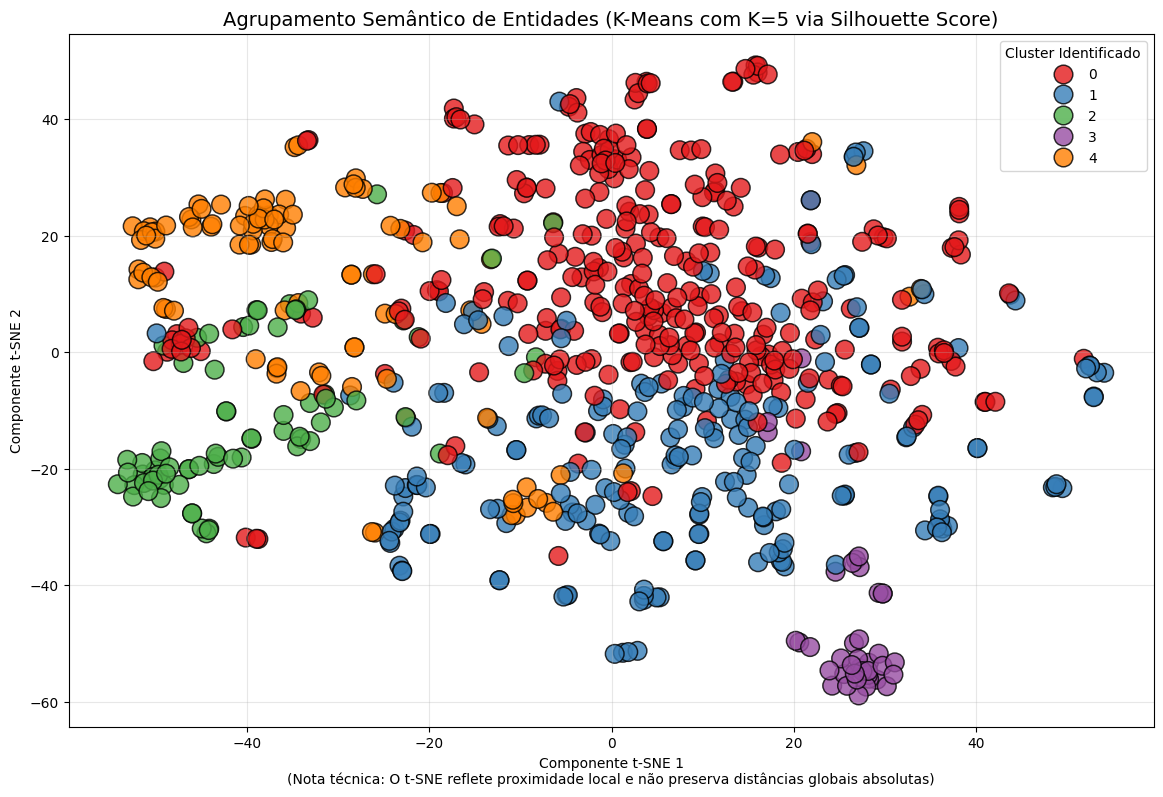

In [7]:
from sklearn.metrics import silhouette_score

# Compilação e achatamento (flatten) das entidades encontradas
todas_palavras = []
for lista in df_processado['Entidades_Extraidas']:
    if lista:
        todas_palavras.extend([palavra.strip() for palavra in lista.split(",")])

entidades_unicas = list(set(todas_palavras))
print(f"Total de entidades únicas prontas para vetorização: {len(entidades_unicas)}")

if len(entidades_unicas) >= 5:
    print("Gerando vetores densos (Embeddings) com SentenceTransformers...")
    
    # Utilização de modelo otimizado especificamente para similaridade semântica
    modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')
    embeddings = modelo_emb.encode(entidades_unicas)
    
    # Otimização do hiperparâmetro k (número de clusters) usando Silhouette Score
    melhor_k = 2
    melhor_score = -1
    max_k = min(8, len(entidades_unicas) - 1)
    
    for k in range(2, max_k + 1):
        kmeans_temp = KMeans(n_clusters=k, random_state=42)
        labels_temp = kmeans_temp.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels_temp)
        if score > melhor_score:
            melhor_score = score
            melhor_k = k
            
    print(f"Otimização matemática concluída: O algoritmo elegeu k={melhor_k} clusters.")
    
    # Execução do K-Means com o parâmetro validado
    kmeans = KMeans(n_clusters=melhor_k, random_state=42)
    clusters = kmeans.fit_predict(embeddings)
    
    # Redução de dimensionalidade para visualização bidimensional adaptativa
    perplexity_val = min(10, len(entidades_unicas) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, init='pca')
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Construção do espaço visual (Foco na geometria estrutural, mitigando overplotting)
    plt.figure(figsize=(14, 9))
    sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=clusters, palette="Set1", s=180, alpha=0.8, edgecolor='black')
        
    plt.title(f"Agrupamento Semântico de Entidades (K-Means com K={melhor_k} via Silhouette Score)", fontsize=14)
    plt.xlabel("Componente t-SNE 1\n(Nota técnica: O t-SNE reflete proximidade local e não preserva distâncias globais absolutas)")
    plt.ylabel("Componente t-SNE 2")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Cluster Identificado")
    plt.show()
else:
    print("Volume de entidades insuficiente para análise de agrupamento. Expanda o TRAIN_DATA.")